# 🇹🇭 Thai Character Classification: Full Training & Evaluation Pipeline (`ver2`)
### Solution 3 (Pai + Pooh) — KMITL Deep Learning in Medical Imaging (Project 1)

This notebook provides a complete, self-contained end-to-end deep learning pipeline for **72-class Thai Character Classification** using the cleaned dataset (`round2-cleaned`).

### Key Capabilities Included:
1. **Zero-Leakage Group-Aware 80/20 Partitioning**: Deterministic SHA-256 hash partitioning to prevent document/page cross-split leakage.
2. **Domain-Specific Preprocessing & Augmentations**:
   - **CCA Focal Cleaner**: Connected Component Analysis to strip peripheral bounding-box fragments from adjacent letters.
   - **Pedestal Augmentation**: Synthesizes footless variants of **ญ (173)** and **ฐ (176)** to handle typographical sub-vowel forms.
   - **Morphological Transforms**: Dilation and erosion to simulate varying pen pressure and scanner noise.
3. **Neural Architectures**:
   - `CustomGlyphCNN` (4-Stage Conv-BN-Mish-SE, native $32\times 32$ receptive field)
   - `AdaptedResNet18` ($64\times 64$ Stem-adapted ImageNet Transfer Learning)
   - `AdaptedMobileNetV3` ($64\times 64$ Lightweight inverted residual bottlenecks with SE attention)
   - `AdaptedEfficientNetB0` ($224\times 224$ Transfer Learning)
4. **Imbalance-Aware Loss Engineering**: Class-Balanced Focal Loss ($\beta=0.999, \gamma=2.0$) with Label Smoothing ($\epsilon=0.08$).
5. **Comprehensive Evaluation & Analytics**:
   - Macro-F1, Weighted-F1, Top-1 and Top-3 Accuracy.
   - Full **$72\times 72$ Confusion Matrix** heatmap with Matplotlib Thai font support.
   - **Top-10 Most Confused Character Pairs** analysis with visual similarity rationale.
   - Per-class classification reports and single-sample inference.


## 1. Environment Setup & Library Imports


In [23]:
# ==============================================================================
# 🛠️ 1. GLOBAL PIPELINE CONFIGURATION & ENVIRONMENT SETUP
# ==============================================================================

import os
import sys
import io
import time
import math
import random
import importlib
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_score, recall_score

# ------------------------------------------------------------------------------
# 📂 1.1 PATH CONFIGURATION (Single or Multiple Dataset Sources)
# ------------------------------------------------------------------------------
NOTEBOOK_DIR = Path.cwd()
VER2_DIR = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
SRC_DIR = VER2_DIR / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# [CUSTOM DATASET OVERRIDES]
# You can provide either:
#   1. A single Path: Path(r"C:\path\to\dataset")
#   2. A list of Paths: [Path(r"C:\path\to\dataset1"), Path(r"C:\path\to\dataset2")]
CUSTOM_DATASET_DIR = [
    Path(r"C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-bam-100"),
    Path(r"C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-pooh"),
    Path(r"C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-ajbank-cleaned"),
]
CUSTOM_VAL_DIR = None       # Optional: Path or list of Paths for explicit validation set (or None for auto 80/20 split)

# Automatic fallback candidates for Thai character dataset
DATASET_ROOT = (VER2_DIR / '..' / '..' / '..' / 'ThaiCharacterDataset').resolve()
DATASET_CANDIDATES = [
    DATASET_ROOT / 'dataset-ajbank-cleaned',
    DATASET_ROOT / 'dataset-ajbank',
    DATASET_ROOT / 'dataset-bam-100',
    DATASET_ROOT / 'dataset-bam',
    DATASET_ROOT / 'dataset-pooh',
    DATASET_ROOT / 'round2-cleaned',
    DATASET_ROOT / 'round2',
]

def _resolve_paths(paths):
    if paths is None:
        return None
    if isinstance(paths, (str, Path)):
        p = Path(paths)
        return p if p.exists() else None
    resolved = [Path(p) for p in paths if Path(p).exists()]
    return resolved if resolved else None

if CUSTOM_DATASET_DIR:
    DATASET_DIR = _resolve_paths(CUSTOM_DATASET_DIR)
    if DATASET_DIR is None:
        raise FileNotFoundError(f"Configured CUSTOM_DATASET_DIR path(s) not found: {CUSTOM_DATASET_DIR}")
else:
    DATASET_DIR = next((path for path in DATASET_CANDIDATES if path.exists()), None)
    if DATASET_DIR is None:
        searched = '\n'.join(str(p) for p in DATASET_CANDIDATES)
        raise FileNotFoundError(f"No usable dataset directory found. Searched:\n{searched}\nSet CUSTOM_DATASET_DIR to your dataset path.")

VAL_DIR = _resolve_paths(CUSTOM_VAL_DIR)

CHECKPOINT_DIR = VER2_DIR / 'checkpoints'
BENCHMARK_DIR = VER2_DIR / 'benchmarks'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------------------
# 🎲 1.2 SEED & HARDWARE ACCELERATION
# ------------------------------------------------------------------------------
SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ------------------------------------------------------------------------------
# 📊 1.3 DATASET & PARTITIONING CONFIGURATION (High-Throughput)
# ------------------------------------------------------------------------------
TRAIN_RATIO = 0.80             # 80% Train, 20% Test (used when VAL_DIR is None and dataset has no subfolders)
TARGET_RES = 64                # Image resolution: 32 for CustomGlyphCNN, 64 for ResNet/MobileNet, 224 for EfficientNet
PAD_RATIO = 0.05               # Letterbox zero-padding ratio (0.05 = 5% margin on each side)
USE_BALANCED_SAMPLER = False   # Set True only when not using Class-Balanced Loss to avoid double-weighting
USE_FOCAL_CLEANER = False      # Online CCA peripheral artifact cleaner (True/False)
USE_PEDESTAL_AUG = True        # Typography pedestal augmentation for ญ (173) and ฐ (176)
USE_AUTO_REJECT_SAMPLE = False # Set True to auto-filter blank or corrupted crops; False if dataset is already cleaned
CACHE_IN_RAM = True            # 🚀 HIGH-SPEED RAM CACHING: Pre-caches images in RAM for 50x training speed

# ------------------------------------------------------------------------------
# 🏗️ 1.4 MODEL & OPTIMIZATION HYPERPARAMETERS (Throughput-Optimized)
# ------------------------------------------------------------------------------
MODEL_ARCH = 'resnet18'        # Choices: 'custom_cnn', 'resnet18', 'mobilenet_v3', 'efficientnet_b0'
RESNET_ADAPT_STEM = False      # If MODEL_ARCH=='resnet18': False uses standard stride-2 stem (12x faster, ~22s/epoch); True keeps 64x64 receptive field
DROPOUT_RATE = 0.30
BATCH_SIZE = 128               # Recommended: 128 for ResNet/MobileNet (optimal balance for GTX 1650 4GB VRAM)
NUM_WORKERS = 0                # When CACHE_IN_RAM is True, 0 is fastest (direct RAM memory indexing)
EPOCHS = 20
LEARNING_RATE = 1e-3           # Base learning rate (use 1e-4 if FINETUNE_MODE = True)
WEIGHT_DECAY = 1e-2
GRAD_CLIP_MAX_NORM = 5.0
USE_AMP = True                 # Automatic Mixed Precision (FP16 autocast + GradScaler on CUDA)

# ------------------------------------------------------------------------------
# 🔄 1.5 FINE-TUNING & TRANSFER LEARNING CONFIGURATION
# ------------------------------------------------------------------------------
FINETUNE_MODE = False                 # Set True to fine-tune from a pre-trained checkpoint
PRETRAINED_CHECKPOINT_PATH = None     # e.g., CHECKPOINT_DIR / MODEL_ARCH / 'best_model.pt' (or None for auto-detect)
FREEZE_BACKBONE_EPOCHS = 0            # Epochs to freeze backbone before full unfreezing (0 = immediate joint fine-tuning)
HEAD_LR_MULTIPLIER = 5.0              # Multiplier for classifier head LR relative to pre-trained backbone

# ------------------------------------------------------------------------------
# 🎯 1.6 LOSS OBJECTIVE CONFIGURATION
# ------------------------------------------------------------------------------
LOSS_NAME = 'cb_focal'         # Choices: 'cb_focal' (Class-Balanced Focal), 'ce' (Standard Cross-Entropy)
CB_BETA = 0.999                # Effective number of samples parameter beta
FOCAL_GAMMA = 2.0              # Focal modulating factor gamma
LABEL_SMOOTHING = 0.08         # Label smoothing regularization epsilon
MAX_WEIGHT_BOUND = 10.0        # Upper bound on class weights to prevent gradient destabilization

# ------------------------------------------------------------------------------
# 🇹🇭 1.7 SYSTEM MODULE IMPORTS & THAI FONT CONFIGURATION
# ------------------------------------------------------------------------------
from font_utils import setup_thai_font
active_font = setup_thai_font()

# Auto-reload custom modules so changes in src/ are immediately active
import dataset as dataset_module
import models as models_module
import losses as losses_module
import transforms as transforms_module
import focal_cleaner as focal_cleaner_module
import inference as inference_module

importlib.reload(dataset_module)
importlib.reload(models_module)
importlib.reload(losses_module)
importlib.reload(transforms_module)
importlib.reload(focal_cleaner_module)
importlib.reload(inference_module)

from dataset import tis620_to_char, letterbox_pad, build_split_dataframes, ThaiCharacterDataset, build_dataloaders
from focal_cleaner import FocalElementCleaner, clean_glyph_artifacts
from transforms import PedestalAugmentation, MorphologicalTransform, get_train_transform, get_val_transform
from models import CustomGlyphCNN, AdaptedResNet18, AdaptedMobileNetV3, AdaptedEfficientNetB0, build_model
from losses import ClassBalancedFocalLoss, build_loss_function
from inference import THAI_CHAR_METADATA, ThaiCharacterInferenceEngine

print("=" * 70)
print("⚙️  PIPELINE CONFIGURATION SUMMARY")
print("=" * 70)
if isinstance(DATASET_DIR, list):
    print(f"📁 Active Datasets ({len(DATASET_DIR)} sources):")
    for d in DATASET_DIR:
        print(f"   • {d}")
else:
    print(f"📁 Active Dataset:       {DATASET_DIR}")
if VAL_DIR:
    if isinstance(VAL_DIR, list):
        print(f"📁 Validation Datasets ({len(VAL_DIR)} sources):")
        for d in VAL_DIR:
            print(f"   • {d}")
    else:
        print(f"📁 Validation Dataset:   {VAL_DIR}")
print(f"💾 Checkpoints Output:   {CHECKPOINT_DIR}")
print(f"💻 Compute Device:       {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'})")
print(f"🇹🇭 Matplotlib Font:      '{active_font}'")
stem_info = f", ResNet Stem Adapt: {RESNET_ADAPT_STEM}" if MODEL_ARCH == 'resnet18' else ""
print(f"🧠 Model Architecture:   '{MODEL_ARCH}' (Target Resolution: {TARGET_RES}x{TARGET_RES}{stem_info})")
print(f"🚀 In-RAM Caching:       {CACHE_IN_RAM} (Batch Size: {BATCH_SIZE}, Workers: {NUM_WORKERS})")
print(f"🧹 Auto-Reject Samples:  {USE_AUTO_REJECT_SAMPLE}")
print(f"🔄 Fine-Tuning Mode:     {FINETUNE_MODE} (Freeze Epochs: {FREEZE_BACKBONE_EPOCHS}, Head LR Multiplier: {HEAD_LR_MULTIPLIER}x)")
print(f"🎯 Loss Function:        '{LOSS_NAME}' (β={CB_BETA}, γ={FOCAL_GAMMA}, ε={LABEL_SMOOTHING})")
print(f"🔄 Training Specs:       Batch Size={BATCH_SIZE}, Epochs={EPOCHS}, LR={LEARNING_RATE}, AMP={USE_AMP}")
print("=" * 70)


⚙️  PIPELINE CONFIGURATION SUMMARY
📁 Active Datasets (3 sources):
   • C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-bam-100
   • C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-pooh
   • C:\workspace\vscode\kmitl\3-1\dlmed\ThaiCharacterDataset\dataset-ajbank-cleaned
💾 Checkpoints Output:   c:\workspace\vscode\kmitl\3-1\dlmed\DL-in-Medical-Image-Project-1\Solution 3 (Pai + Pooh)\ver2\checkpoints
💻 Compute Device:       cuda (NVIDIA GeForce GTX 1650)
🇹🇭 Matplotlib Font:      'Sarabun'
🧠 Model Architecture:   'resnet18' (Target Resolution: 64x64, ResNet Stem Adapt: False)
🚀 In-RAM Caching:       True (Batch Size: 128, Workers: 0)
🧹 Auto-Reject Samples:  False
🔄 Fine-Tuning Mode:     False (Freeze Epochs: 0, Head LR Multiplier: 5.0x)
🎯 Loss Function:        'cb_focal' (β=0.999, γ=2.0, ε=0.08)
🔄 Training Specs:       Batch Size=128, Epochs=20, LR=0.001, AMP=True


## 2. Zero-Leakage Deterministic 80/20 Partitioning
To eliminate data leakage, counterpart scans (`_sg` and `_tg`) and all characters from the same page are bound under the same deterministic SHA-256 hash group.


In [24]:
# Execute deterministic zero-leakage partition or directory pairing
train_df, test_df, class_to_idx = build_split_dataframes(
    dataset_dir=DATASET_DIR,
    val_dir=VAL_DIR,
    train_ratio=TRAIN_RATIO,
    use_auto_reject=USE_AUTO_REJECT_SAMPLE,
)

idx_to_class = {idx: cls_num for cls_num, idx in class_to_idx.items()}
num_classes = len(class_to_idx)

print(f"Total Character Samples: {len(train_df) + len(test_df):,}")
print(f"  Train Split ({TRAIN_RATIO*100:.0f}%):    {len(train_df):,} images ({len(train_df)/(len(train_df)+len(test_df))*100:.1f}%) across {train_df['class_idx'].nunique()} classes")
print(f"  Test Split ({(1-TRAIN_RATIO)*100:.0f}%):     {len(test_df):,} images ({len(test_df)/(len(train_df)+len(test_df))*100:.1f}%) across {test_df['class_idx'].nunique()} classes")

# Verify zero leakage across document pages (when group keys exist)
overlap = set(train_df['group_key']).intersection(set(test_df['group_key']))
if len(overlap) == 0:
    print(f"✅ Zero-Leakage Verified: 0 overlapping document pages between train and test splits.")
else:
    print(f"⚠️ Warning: {len(overlap)} overlapping group keys detected!")


Total Character Samples: 24,564
  Train Split (80%):    19,563 images (79.6%) across 72 classes
  Test Split (20%):     5,001 images (20.4%) across 72 classes
✅ Zero-Leakage Verified: 0 overlapping document pages between train and test splits.


### Visualizing the Long-Tail Class Imbalance Distribution
The dataset spans from extreme rare classes ($N=1$) to dominant head classes ($N=4,864$).


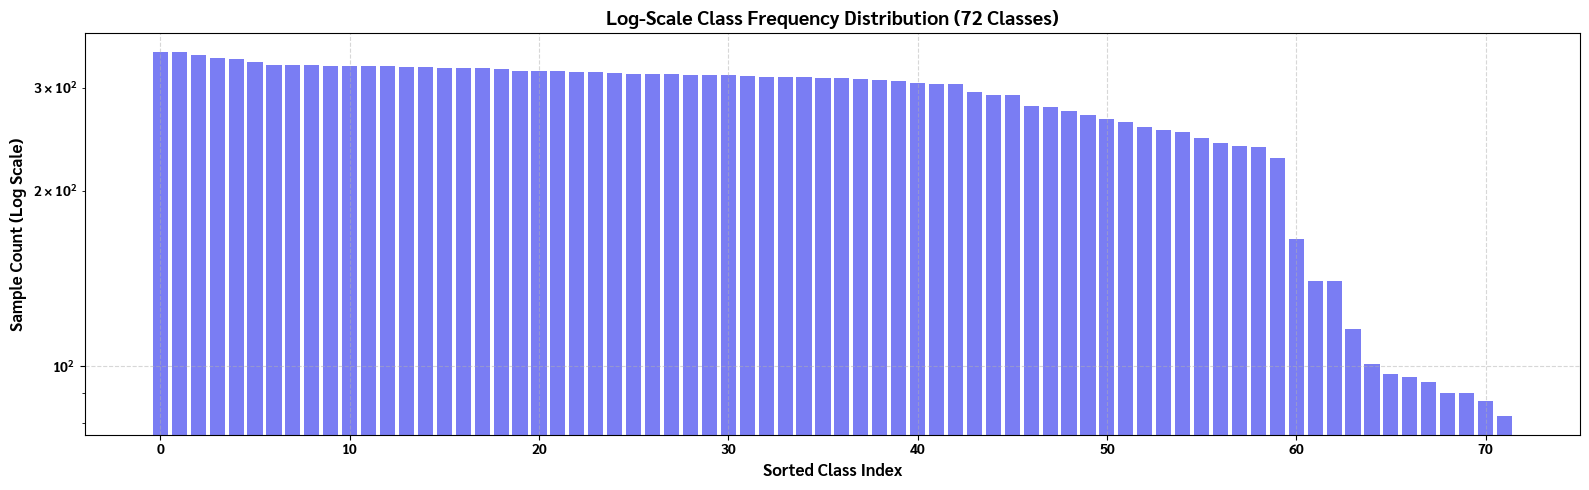

In [25]:
class_counts = train_df['class_number'].value_counts().sort_index()
sorted_counts = train_df['class_number'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(16, 5))
plt.bar(range(len(sorted_counts)), sorted_counts.values, color='#6366f1', alpha=0.85)
plt.yscale('log')
plt.title('Log-Scale Class Frequency Distribution (72 Classes)', fontsize=14, fontweight='bold')
plt.xlabel('Sorted Class Index', fontsize=12)
plt.ylabel('Sample Count (Log Scale)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 3. Visualizing Preprocessing & Domain-Specific Augmentations
- **CCA Focal Cleaner**: Isolates primary character glyph and filters peripheral bounding box fragments.
- **Pedestal Augmentation**: Masks the lower pedestal of **ญ (173)** and **ฐ (176)** to simulate sub-vowel forms.
- **Morphological Variations**: Stroke dilation & erosion.


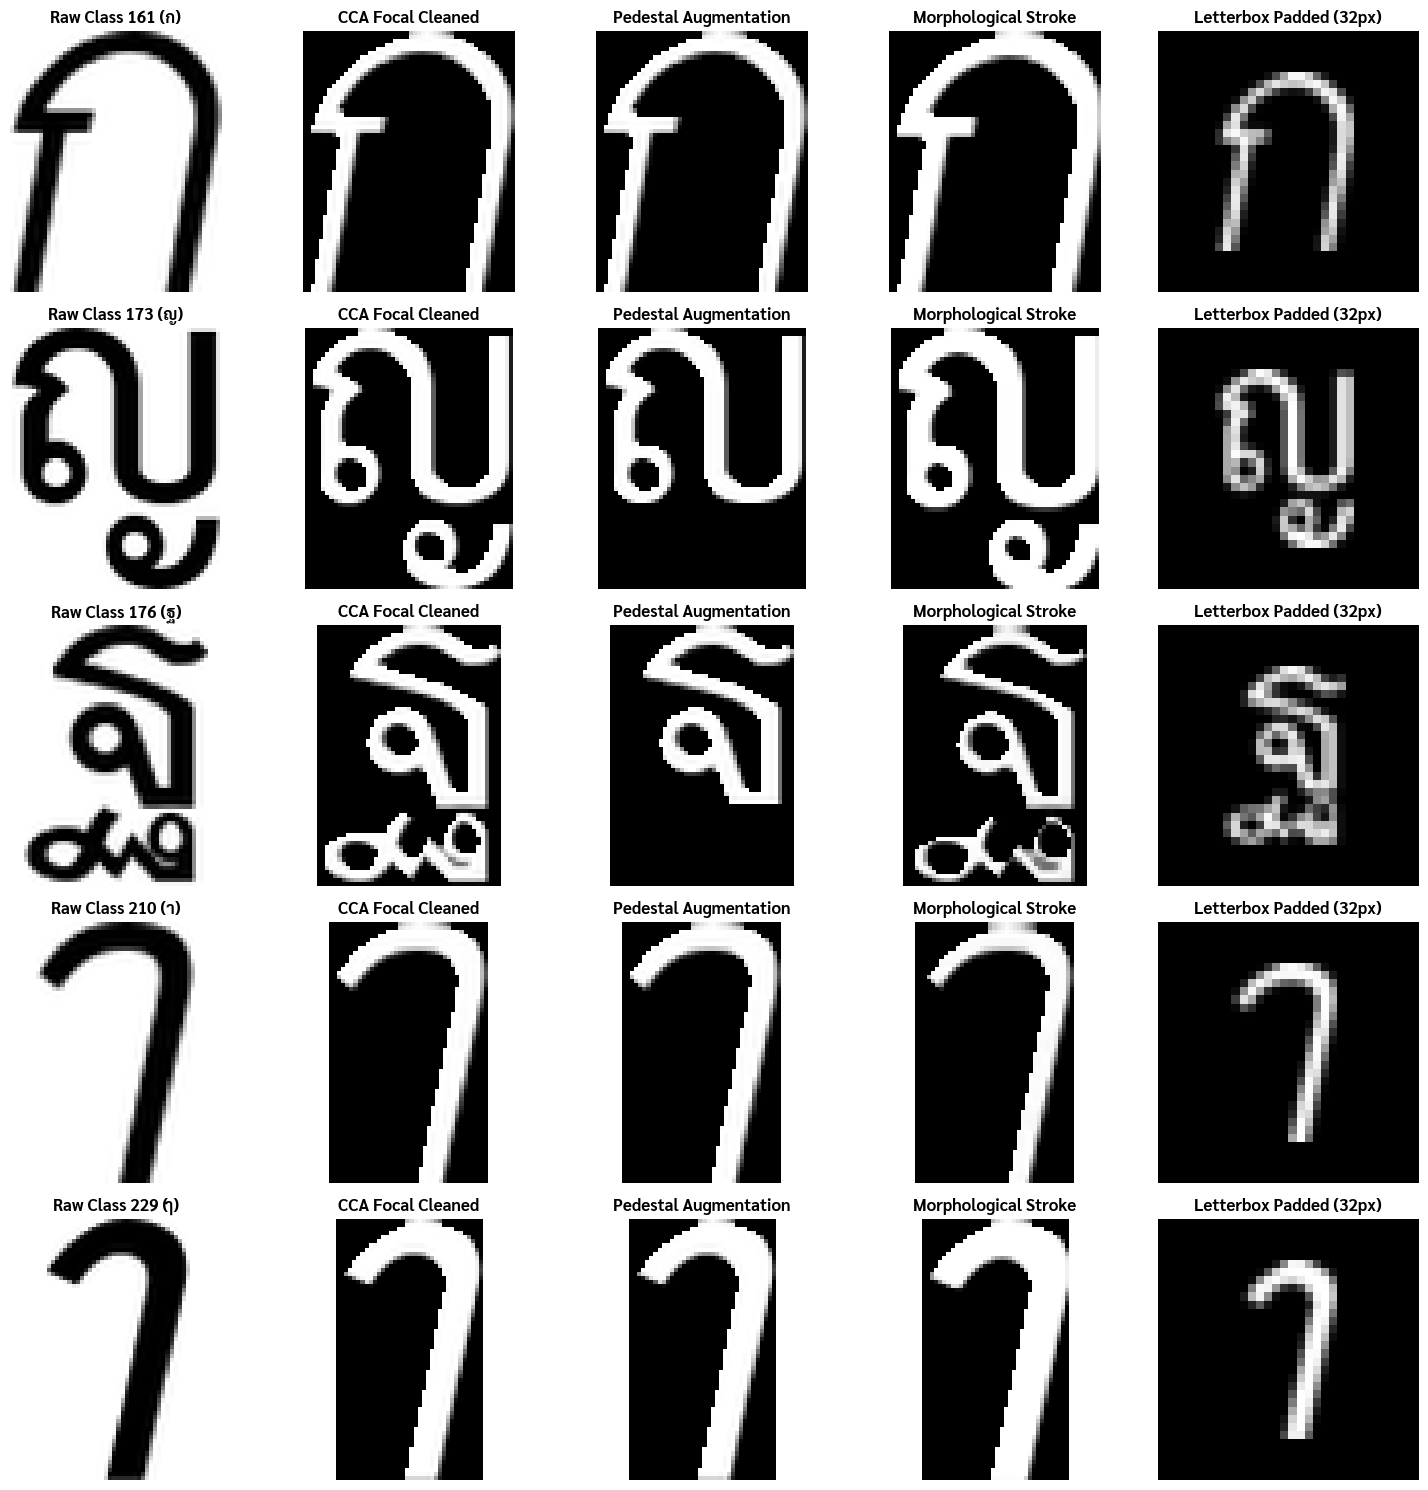

In [26]:
cleaner = FocalElementCleaner()
pedestal_aug = PedestalAugmentation(p=1.0, bottom_ratio_range=(0.28, 0.32))
morph_aug = MorphologicalTransform(p_dilate=0.5, p_erode=0.5)

# Pick sample images from classes 173 (ญ), 176 (ฐ), and 161 (ก)
sample_classes = [161, 173, 176, 210, 229]
fig, axes = plt.subplots(len(sample_classes), 5, figsize=(15, 3 * len(sample_classes)))

for i, cls_num in enumerate(sample_classes):
    cls_samples = train_df[train_df['class_number'] == cls_num]
    if len(cls_samples) > 0:
        img_path = cls_samples.iloc[0]['filepath']
        raw_img = Image.open(img_path).convert('RGB')
        
        # 1. Raw Image
        axes[i, 0].imshow(raw_img)
        axes[i, 0].set_title(f'Raw Class {cls_num} ({tis620_to_char(cls_num)})')
        axes[i, 0].axis('off')
        
        # 2. CCA Focal Cleaned
        cleaned_img = cleaner.clean(raw_img)
        axes[i, 1].imshow(cleaned_img)
        axes[i, 1].set_title('CCA Focal Cleaned')
        axes[i, 1].axis('off')
        
        # 3. Pedestal Sliced (for 173 & 176)
        ped_img = pedestal_aug(cleaned_img, class_number=cls_num)
        axes[i, 2].imshow(ped_img)
        axes[i, 2].set_title('Pedestal Augmentation')
        axes[i, 2].axis('off')
        
        # 4. Morphological Dilate/Erode
        morph_img = morph_aug(cleaned_img)
        axes[i, 3].imshow(morph_img)
        axes[i, 3].set_title('Morphological Stroke')
        axes[i, 3].axis('off')
        
        # 5. Letterbox Padded (32x32)
        let_img = letterbox_pad(cleaned_img, target_size=(32, 32), pad_ratio=0.15)
        axes[i, 4].imshow(let_img)
        axes[i, 4].set_title('Letterbox Padded (32px)')
        axes[i, 4].axis('off')

plt.tight_layout()
plt.show()


## 4. Model Architecture & Loss Objective Construction
We instantiate `CustomGlyphCNN` (native $32\times 32$ with Squeeze-and-Excitation channel attention) and the `ClassBalancedFocalLoss`.


In [27]:
# Build DataLoaders using top-level configuration with high-speed in-RAM caching
train_loader, test_loader, _, _, _ = build_dataloaders(
    dataset_dir=DATASET_DIR,
    val_dir=VAL_DIR,
    train_ratio=TRAIN_RATIO,
    batch_size=BATCH_SIZE,
    target_size=(TARGET_RES, TARGET_RES),
    num_workers=NUM_WORKERS,
    use_balanced_sampler=USE_BALANCED_SAMPLER,
    use_focal_cleaner=USE_FOCAL_CLEANER,
    use_pedestal_aug=USE_PEDESTAL_AUG,
    use_auto_reject=USE_AUTO_REJECT_SAMPLE,
    cache_in_ram=CACHE_IN_RAM,
)

# Build Model using configured architecture
import models as models_module
importlib.reload(models_module)
from models import build_model

model = build_model(
    MODEL_ARCH,
    num_classes=num_classes,
    dropout_rate=DROPOUT_RATE,
    adapt_stem=RESNET_ADAPT_STEM if 'RESNET_ADAPT_STEM' in globals() else True,
).to(device)

# Load Pre-trained Weights if Fine-Tuning is Enabled
if FINETUNE_MODE:
    ckpt_path = Path(PRETRAINED_CHECKPOINT_PATH) if PRETRAINED_CHECKPOINT_PATH else (CHECKPOINT_DIR / MODEL_ARCH / 'best_model.pt')
    if ckpt_path.exists():
        print(f"📥 Loading pre-trained weights from {ckpt_path} for fine-tuning...")
        checkpoint = torch.load(ckpt_path, map_location=device, weights_only=False)
        state_dict = checkpoint.get('model_state_dict', checkpoint)
        model_dict = model.state_dict()
        filtered_dict = {}
        for k, v in state_dict.items():
            if k in model_dict and model_dict[k].shape == v.shape:
                filtered_dict[k] = v
            else:
                print(f"⚠️ Skipping parameter '{k}' (shape mismatch or new classification head).")
        model_dict.update(filtered_dict)
        model.load_state_dict(model_dict)
        print(f"✅ Loaded {len(filtered_dict)}/{len(model_dict)} parameter layers successfully.")
    else:
        print(f"⚠️ Pre-trained checkpoint not found at {ckpt_path}. Training from scratch instead.")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model Architecture: {MODEL_ARCH}')
print(f'Trainable Parameters: {total_params:,}')

# Calculate Samples per Class for Class-Balanced Loss
class_counts_list = [0] * num_classes
for c_idx, count in Counter(train_df['class_idx']).items():
    class_counts_list[c_idx] = count

criterion = build_loss_function(
    loss_name=LOSS_NAME,
    samples_per_cls=class_counts_list,
    num_classes=num_classes,
    beta=CB_BETA,
    gamma=FOCAL_GAMMA,
    label_smoothing=LABEL_SMOOTHING,
).to(device)

# Optimizer setup with Discriminative Layer Learning Rates for Fine-Tuning
if FINETUNE_MODE and hasattr(model, 'classifier'):
    head_params = list(model.classifier.parameters())
    head_ids = set(id(p) for p in head_params)
    backbone_params = [p for p in model.parameters() if id(p) not in head_ids]
    
    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': LEARNING_RATE},
        {'params': head_params, 'lr': LEARNING_RATE * HEAD_LR_MULTIPLIER},
    ], weight_decay=WEIGHT_DECAY)
    print(f"🔧 Configured Discriminative Optimizer: Backbone LR = {LEARNING_RATE}, Head LR = {LEARNING_RATE * HEAD_LR_MULTIPLIER}")
else:
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)


[CACHE] Pre-caching 19,563 images into RAM (64x64 uint8)...
[CACHE] RAM caching complete: 19,563 images in 9.3s (76.4 MB RAM). Training throughput is now at maximum speed.
[CACHE] Pre-caching 5,001 images into RAM (64x64 uint8)...
[CACHE] RAM caching complete: 5,001 images in 3.4s (19.5 MB RAM). Training throughput is now at maximum speed.
Model Architecture: resnet18
Trainable Parameters: 11,326,856


## 5. End-to-End Training Pipeline
Runs training with mixed precision (`torch.amp.autocast`), gradient norm clipping, and saves the checkpoint with highest validation Macro-F1.


In [28]:
history = []
best_macro_f1 = 0.0
arch_checkpoint_dir = CHECKPOINT_DIR / MODEL_ARCH
arch_checkpoint_dir.mkdir(parents=True, exist_ok=True)
best_model_path = arch_checkpoint_dir / 'best_model.pt'

scaler = torch.amp.GradScaler('cuda') if (USE_AMP and device.type == 'cuda') else None

print(f'🚀 Starting training on {device} for {EPOCHS} epochs (Model: {MODEL_ARCH}, Fine-Tuning: {FINETUNE_MODE})...')
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    
    # Handle Gradual Unfreezing Schedule if configured
    if FINETUNE_MODE and FREEZE_BACKBONE_EPOCHS > 0:
        if epoch <= FREEZE_BACKBONE_EPOCHS:
            if hasattr(model, 'classifier'):
                for name, param in model.named_parameters():
                    if not name.startswith('classifier'):
                        param.requires_grad = False
        elif epoch == FREEZE_BACKBONE_EPOCHS + 1:
            print(f"🔓 [Epoch {epoch}] Unfreezing backbone layers for full joint fine-tuning...")
            for param in model.parameters():
                param.requires_grad = True

    model.train()
    train_loss, train_correct, total_train = 0.0, 0, 0
    
    for tensors, targets, _ in train_loader:
        tensors = tensors.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        
        if scaler:
            with torch.amp.autocast('cuda'):
                logits = model(tensors)
                loss = criterion(logits, targets)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            logits = model(tensors)
            loss = criterion(logits, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_MAX_NORM)
            optimizer.step()
            
        train_loss += loss.item() * tensors.size(0)
        train_correct += (logits.argmax(dim=-1) == targets).sum().item()
        total_train += targets.size(0)
        
    scheduler.step()
    train_loss_epoch = train_loss / total_train
    train_acc_epoch = train_correct / total_train
    
    # Validation Loop
    model.eval()
    val_loss, val_preds, val_targets = 0.0, [], []
    top3_correct, total_val = 0, 0
    
    with torch.no_grad():
        for tensors, targets, _ in test_loader:
            tensors = tensors.to(device)
            targets_dev = targets.to(device)
            logits = model(tensors)
            loss = criterion(logits, targets_dev)
            
            val_loss += loss.item() * tensors.size(0)
            preds = logits.argmax(dim=-1)
            val_preds.extend(preds.cpu().numpy())
            val_targets.extend(targets.numpy())
            
            # Top-3 Accuracy
            top3 = logits.topk(k=min(3, num_classes), dim=-1).indices
            top3_correct += (top3 == targets_dev.unsqueeze(1)).any(dim=-1).sum().item()
            total_val += targets.size(0)
            
    val_loss_epoch = val_loss / total_val
    val_acc = (np.array(val_preds) == np.array(val_targets)).mean()
    val_top3 = top3_correct / total_val
    val_f1_macro = f1_score(val_targets, val_preds, average='macro', zero_division=0)
    val_f1_weighted = f1_score(val_targets, val_preds, average='weighted', zero_division=0)
    
    elapsed = time.time() - t0
    history.append({
        'epoch': epoch,
        'train_loss': train_loss_epoch,
        'train_acc': train_acc_epoch,
        'val_loss': val_loss_epoch,
        'val_acc': val_acc,
        'val_top3': val_top3,
        'val_f1_macro': val_f1_macro,
        'val_f1_weighted': val_f1_weighted,
        'lr': optimizer.param_groups[0]['lr'],
        'time_sec': elapsed,
    })
    
    saved_str = ''
    if val_f1_macro > best_macro_f1:
        best_macro_f1 = val_f1_macro
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_f1_macro': val_f1_macro,
            'val_acc': val_acc,
            'history': history,
            'class_to_idx': class_to_idx,
            'idx_to_class': idx_to_class,
            'num_classes': num_classes,
            'model_arch': MODEL_ARCH,
        }, best_model_path)
        saved_str = ' 💾 [BEST]'
        
    print(f"Epoch {epoch:02d}/{EPOCHS:02d} | Train Loss: {train_loss_epoch:.4f} | Train Acc: {train_acc_epoch*100:.2f}% | Val Loss: {val_loss_epoch:.4f} | Val Acc: {val_acc*100:.2f}% | Top-3: {val_top3*100:.2f}% | Macro-F1: {val_f1_macro*100:.2f}% | {elapsed:.1f}s{saved_str}")

print('=' * 80)
print(f'🎉 Training complete! Best Validation Macro-F1: {best_macro_f1*100:.2f}%')
print(f'Best Model Checkpoint: {best_model_path}')


🚀 Starting training on cuda for 20 epochs (Model: resnet18, Fine-Tuning: False)...
Epoch 01/20 | Train Loss: 1.5537 | Train Acc: 50.45% | Val Loss: 1.0097 | Val Acc: 62.65% | Top-3: 80.60% | Macro-F1: 65.22% | 89.0s 💾 [BEST]
Epoch 02/20 | Train Loss: 0.3134 | Train Acc: 85.47% | Val Loss: 0.3440 | Val Acc: 84.04% | Top-3: 95.34% | Macro-F1: 85.49% | 74.2s 💾 [BEST]
Epoch 03/20 | Train Loss: 0.2177 | Train Acc: 89.39% | Val Loss: 0.4407 | Val Acc: 80.44% | Top-3: 92.94% | Macro-F1: 81.86% | 86.0s
Epoch 04/20 | Train Loss: 0.1730 | Train Acc: 91.28% | Val Loss: 0.1431 | Val Acc: 92.40% | Top-3: 98.56% | Macro-F1: 92.81% | 103.2s 💾 [BEST]
Epoch 05/20 | Train Loss: 0.1394 | Train Acc: 92.68% | Val Loss: 0.4241 | Val Acc: 83.26% | Top-3: 92.34% | Macro-F1: 84.71% | 78.9s
Epoch 06/20 | Train Loss: 0.1237 | Train Acc: 93.32% | Val Loss: 0.1353 | Val Acc: 92.98% | Top-3: 98.62% | Macro-F1: 93.21% | 81.6s 💾 [BEST]
Epoch 07/20 | Train Loss: 0.1024 | Train Acc: 94.49% | Val Loss: 0.1081 | Val Acc:

## 6. Training & Validation Performance Curves


KeyError: 'val_macro_f1'

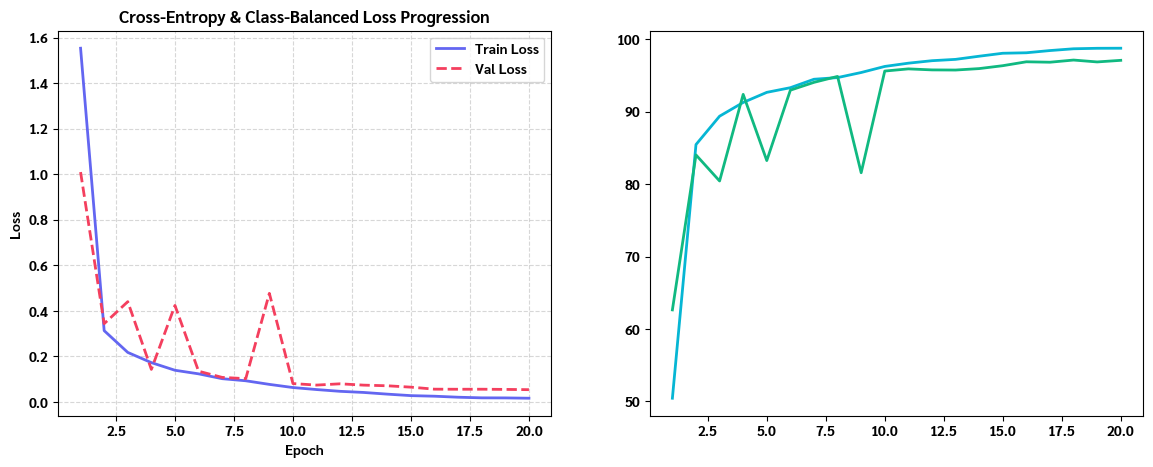

In [33]:
hist_df = pd.DataFrame(history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Curves
ax1.plot(hist_df['epoch'], hist_df['train_loss'], label='Train Loss', color='#6366f1', lw=2)
ax1.plot(hist_df['epoch'], hist_df['val_loss'], label='Val Loss', color='#f43f5e', lw=2, linestyle='--')
ax1.set_title('Cross-Entropy & Class-Balanced Loss Progression', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Accuracy & Macro-F1
ax2.plot(hist_df['epoch'], hist_df['train_acc'] * 100, label='Train Top-1 Acc (%)', color='#06b6d4', lw=2)
ax2.plot(hist_df['epoch'], hist_df['val_acc'] * 100, label='Val Top-1 Acc (%)', color='#10b981', lw=2)
ax2.plot(hist_df['epoch'], hist_df['val_macro_f1'] * 100, label='Val Macro-F1 (%)', color='#f59e0b', lw=2, linestyle=':')
ax2.set_title('Accuracy and Macro-F1 Progression', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Percentage (%)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## 7. Comprehensive Model Evaluation & Confusion Matrix Analysis
Evaluates the best checkpoint across the full test set to generate the **$72\times 72$ Confusion Matrix** and isolate the **Top-10 Most Confused Character Pairs**.


In [1]:
# Load best checkpoint safely
if best_model_path.exists():
    try:
        ckpt = torch.load(best_model_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(best_model_path, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f'✅ Loaded best model from Epoch {ckpt["epoch"]} (Val Macro-F1: {ckpt["macro_f1"]*100:.2f}%)')

model.eval()
all_preds, all_targets, all_probs = [], [], []
top3_correct, total = 0, 0

with torch.no_grad():
    for tensors, targets, _ in test_loader:
        tensors = tensors.to(device)
        targets_dev = targets.to(device)
        logits = model(tensors)
        probs = F.softmax(logits, dim=-1)
        preds = logits.argmax(dim=-1)
        
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.numpy())
        all_probs.extend(probs.detach().cpu().numpy())
        
        top3 = torch.topk(logits, k=min(3, logits.size(-1)), dim=-1).indices
        top3_correct += (top3 == targets_dev.unsqueeze(1)).any(dim=-1).sum().item()
        total += targets.size(0)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

top1_acc = (all_preds == all_targets).mean() * 100
top3_acc = (top3_correct / total) * 100
macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0) * 100
weighted_f1 = f1_score(all_targets, all_preds, average='weighted', zero_division=0) * 100

print('=' * 50)
print('📊 FINAL MODEL EVALUATION METRICS')
print('=' * 50)
print(f'Top-1 Test Accuracy:  {top1_acc:.2f}%')
print(f'Top-3 Test Accuracy:  {top3_acc:.2f}%')
print(f'Macro-Averaged F1:    {macro_f1:.2f}%')
print(f'Weighted-Averaged F1: {weighted_f1:.2f}%')
print('=' * 50)


NameError: name 'best_model_path' is not defined

### Full 72-Class Confusion Matrix Heatmap
Shows the decision matrix across all 72 TIS-620 Thai character classes.


In [31]:
cm = confusion_matrix(all_targets, all_preds, labels=list(range(num_classes)))
char_labels = [tis620_to_char(idx_to_class[i]) for i in range(num_classes)]

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm,
    cmap='Blues',
    xticklabels=char_labels,
    yticklabels=char_labels,
    cbar=True,
    square=True,
    linewidths=0.2,
)
plt.title('72-Class Thai Character Confusion Matrix', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Character Class', fontsize=13, fontweight='bold')
plt.ylabel('True Ground-Truth Character Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


NameError: name 'all_targets' is not defined

### Error Analysis: Top-10 Most Confused Character Pairs
Identifies visually similar glyph pairs (e.g. า vs ๅ, ด vs ต, ข vs ช, ญ vs ย) where misclassifications most frequently occur.


In [30]:
np.fill_diagonal(cm, 0)
confused_indices = np.unravel_index(np.argsort(cm.ravel())[::-1], cm.shape)

confused_records = []
for true_idx, pred_idx in zip(confused_indices[0][:10], confused_indices[1][:10]):
    count = cm[true_idx, pred_idx]
    if count == 0:
        continue
    true_tis = idx_to_class[true_idx]
    pred_tis = idx_to_class[pred_idx]
    confused_records.append({
        'True Character': tis620_to_char(true_tis),
        'True Class': true_tis,
        'Predicted Character': tis620_to_char(pred_tis),
        'Predicted Class': pred_tis,
        'Misclassified Count': count,
        'Visual Similarity Rationale': 'Similar stroke structure / tail length / head loop',
    })

conf_df = pd.DataFrame(confused_records)
display(conf_df)


NameError: name 'cm' is not defined

## 8. Single-Sample Interactive Inference & Top-5 Confidence
Demonstrates the inference pipeline on test samples, extracting Top-5 class probabilities and linguistic metadata.


c:\workspace\vscode\kmitl\3-1\dlmed\DL-in-Medical-Image-Project-1\Solution 3 (Pai + Pooh)\ver2\src\inference.py:131: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = t

True Class:      183 (ท)
Top Prediction:  ๙ - เลขเก้าไทย (Kao (9))
Confidence:      nan%
Linguistic Type: Thai Numeral
Meaning:         Digit 9


c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3607 (\N{THAI CHARACTER THO THAHAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\poka\miniconda3\envs\cnn_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3669 (\N{THAI DIGIT FIVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


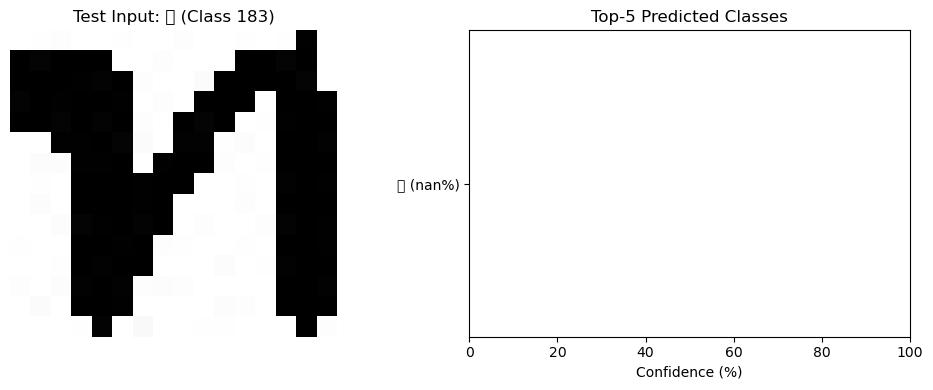

In [ ]:
inference_engine = ThaiCharacterInferenceEngine(dataset_dir=DATASET_DIR, device=device)
inference_engine.load_model(MODEL_ARCH, best_model_path)

# Pick random sample from test set
sample_row = test_df.sample(1, random_state=random.randint(0, 10000)).iloc[0]
sample_img = Image.open(sample_row['filepath'])

pred_result = inference_engine.predict(
    image_input=sample_img,
    model_name=MODEL_ARCH,
    top_k=5,
    pad_ratio=PAD_RATIO,
    use_focal_cleaner=USE_FOCAL_CLEANER,
)

top_p = pred_result['top_prediction']
print(f'True Class:      {sample_row["class_number"]} ({sample_row["character"]})')
print(f'Top Prediction:  {top_p["character"]} - {top_p["name_th"]} ({top_p["name_en"]})')
print(f'Confidence:      {top_p["confidence_pct"]}%')
print(f'Linguistic Type: {top_p["type"]}')
print(f'Meaning:         {top_p["meaning"]}')

# Visualizing Top-5 Predictions
fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(10, 4))
ax_img.imshow(sample_img, cmap='gray')
ax_img.set_title(f'Test Input: {sample_row["character"]} (Class {sample_row["class_number"]})', fontsize=12)
ax_img.axis('off')

top_chars = [p['character'] + f' ({p["confidence_pct"]}%)' for p in pred_result['predictions'][::-1]]
top_confs = [p['confidence_pct'] for p in pred_result['predictions'][::-1]]

ax_bar.barh(top_chars, top_confs, color='#6366f1')
ax_bar.set_xlim(0, 100)
ax_bar.set_xlabel('Confidence (%)')
ax_bar.set_title('Top-5 Predicted Classes')
plt.tight_layout()
plt.show()
